In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.ndimage import gaussian_filter1d
import phate
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [2]:
df = pd.read_csv(r"C:\Users\yezon\Padilla-Coreano_Lab\UMAP\Fiber_Photometry_revisions\Pose_Tracking\HC_automated_social_behaviors.csv")
df_filtered = df[df["brain_region"] == "mPFC"]
feature_cols = [
    "distance_head_res__head_int",
    "angle_head_res__head_int_deg",
    "distance_head_res__hind_int",
    "angle_head_res__hind_int_deg",
    "distance_head_int__hind_res",
    "angle_head_int__hind_res_deg",
    "distance_hind_res__hind_int",
    "velocity_resident",
    "velocity_intruder",
]

x = df_filtered[feature_cols].values
dopa = df_filtered["zscore_DA"].values
df_filtered["behavior_active"] = df_filtered["behavior_active"].fillna("unlabeled")

print(len(df.columns))

17


C:\Users\yezon\AppData\Local\Temp\ipykernel_19756\3077479880.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["behavior_active"] = df_filtered["behavior_active"].fillna("unlabeled")


PCA variance explained: 99.98%
Calculating PHATE...
  Running PHATE on 211663 observations and 50 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 55.15 seconds.
    Calculating affinities...
    Calculated affinities in 5.73 seconds.
  Calculated graph and diffusion operator in 61.38 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 22.46 seconds.
    Calculating KMeans...
    Calculated KMeans in 6.99 seconds.
  Calculated landmark operator in 29.46 seconds.
  Calculating optimal t...
    Automatically selected t = 60
  Calculated optimal t in 2.25 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.83 seconds.
  Calculating metric MDS...
    SGD-MDS may not have converged: stress changed by 3.8% in final iterations. Consider increasing n_iter or adjusting learning_rate.
  Calculated metric MDS in 2.59 seconds.
Calculated PHATE in 101.67 seconds.


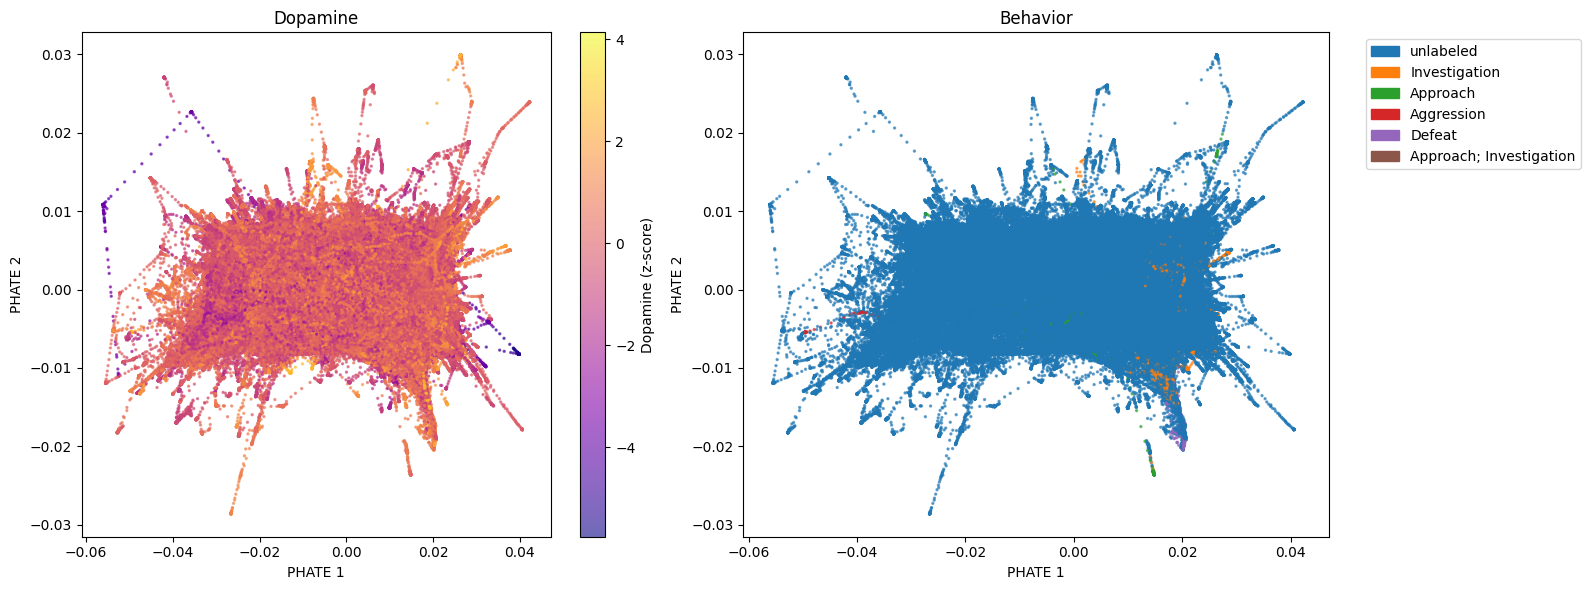

In [3]:
# ── 4. Time-delay embedding ───────────────────────────────────────────────────
def time_delay_embed(X, delay=10):
    n = len(X) - delay + 1
    return np.hstack([X[i:i+n] for i in range(delay)])

delay = 10  # 1.5 seconds at 10 Hz
X_embed = time_delay_embed(x, delay)
dopa_trim = dopa[delay - 1:]                 # align to embedded frames
time_trim = df_filtered["time_s"].values[delay - 1:]

# Optional: smooth dopamine (already z-scored, but can still be noisy)
dopa_smooth = gaussian_filter1d(dopa_trim, sigma=3)

# ── 5. Concatenate dopamine ───────────────────────────────────────────────────
X_full = np.hstack([X_embed, dopa_smooth.reshape(-1, 1)])

# ── 6. Normalize (z-score per feature) ───────────────────────────────────────
# Note: zscore_DA will be re-scaled here alongside kinematics — that's fine
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

# ── 7. Optional PCA ───────────────────────────────────────────────────────────
n_components = min(50, X_scaled.shape[1])
pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA variance explained: {pca.explained_variance_ratio_.sum():.2%}")

# ── 8. PHATE ──────────────────────────────────────────────────────────────────
phate_op = phate.PHATE(
    n_components=2,
    knn=15,
    t="auto",
    random_state=42,
    n_landmark=2000   # fits on landmarks, embeds all points
)
X_phate = phate_op.fit_transform(X_pca)

# Align behavior to embedded frames (same trimming as dopamine)
behavior_trim = df_filtered["behavior_active"].values[delay - 1:]

# Assign a color to each unique behavior
unique_behaviors = pd.Series(behavior_trim).unique()
palette = plt.cm.tab10.colors  # up to 10 distinct colors
color_map = {b: palette[i] for i, b in enumerate(unique_behaviors)}
behavior_colors = [color_map[b] for b in behavior_trim]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: dopamine
sc = axes[0].scatter(X_phate[:, 0], X_phate[:, 1],
                     c=dopa_smooth, cmap="plasma", s=2, alpha=0.6)
plt.colorbar(sc, ax=axes[0], label="Dopamine (z-score)")
axes[0].set_title(f"Dopamine")
axes[0].set_xlabel("PHATE 1"); axes[0].set_ylabel("PHATE 2")

# Right: behavior
axes[1].scatter(X_phate[:, 0], X_phate[:, 1],
                c=behavior_colors, s=2, alpha=0.6)
legend_handles = [mpatches.Patch(color=color_map[b], label=b)
                  for b in unique_behaviors]
axes[1].legend(handles=legend_handles, markerscale=4,
               bbox_to_anchor=(1.05, 1), loc="upper left")
axes[1].set_title(f"Behavior")
axes[1].set_xlabel("PHATE 1"); axes[1].set_ylabel("PHATE 2")

plt.tight_layout()
plt.savefig(f"phate_behavior.png", dpi=150, bbox_inches="tight")
plt.show()

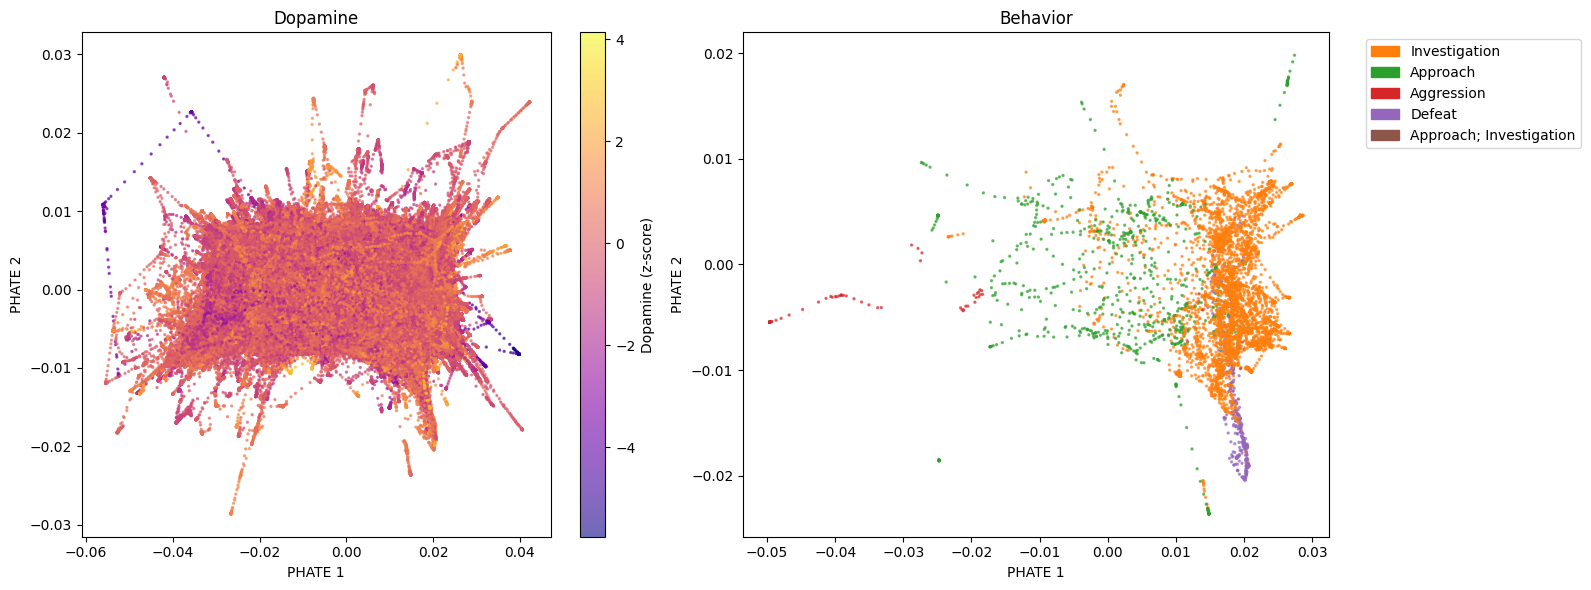

In [4]:
# Mask out unlabeled frames for the behavior plot only
labeled_mask = behavior_trim != "unlabeled"

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: dopamine (all frames)
sc = axes[0].scatter(X_phate[:, 0], X_phate[:, 1],
                     c=dopa_smooth, cmap="plasma", s=2, alpha=0.6)
plt.colorbar(sc, ax=axes[0], label="Dopamine (z-score)")
axes[0].set_title(f"Dopamine")
axes[0].set_xlabel("PHATE 1"); axes[0].set_ylabel("PHATE 2")

# Right: behavior (labeled frames only)
axes[1].scatter(X_phate[labeled_mask, 0], X_phate[labeled_mask, 1],
                c=[behavior_colors[i] for i, m in enumerate(labeled_mask) if m],
                s=2, alpha=0.6)
legend_handles = [mpatches.Patch(color=color_map[b], label=b)
                  for b in unique_behaviors if b != "unlabeled"]
axes[1].legend(handles=legend_handles, markerscale=4,
               bbox_to_anchor=(1.05, 1), loc="upper left")
axes[1].set_title(f"Behavior")
axes[1].set_xlabel("PHATE 1"); axes[1].set_ylabel("PHATE 2")

plt.tight_layout()
plt.savefig(f"phate_behavior.png", dpi=150, bbox_inches="tight")
plt.show()

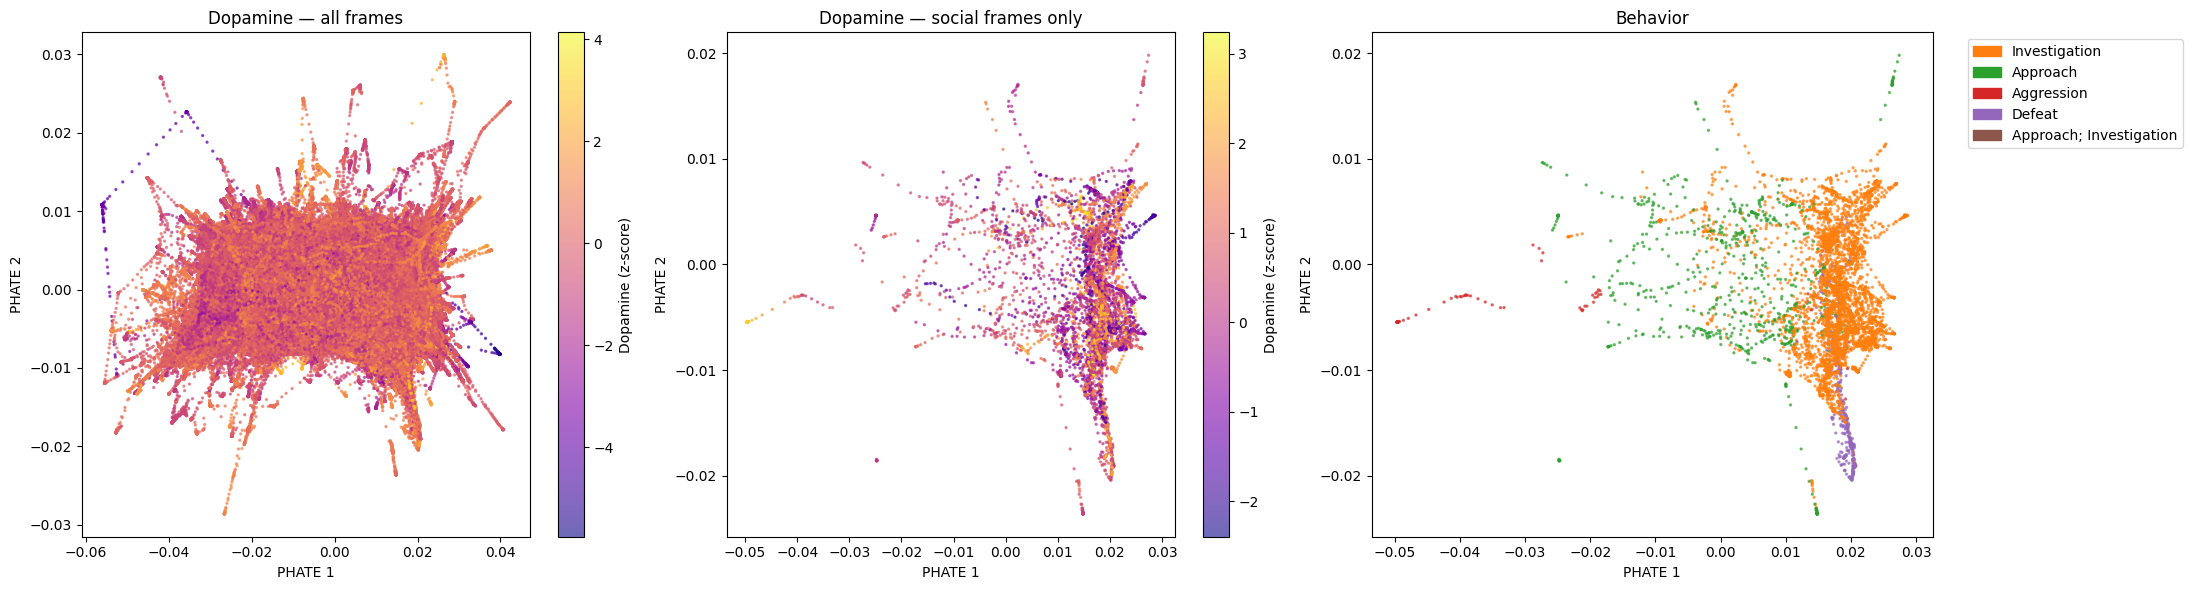

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Left: dopamine (all frames)
sc = axes[0].scatter(X_phate[:, 0], X_phate[:, 1],
                     c=dopa_smooth, cmap="plasma", s=2, alpha=0.6)
plt.colorbar(sc, ax=axes[0], label="Dopamine (z-score)")
axes[0].set_title(f"Dopamine — all frames")
axes[0].set_xlabel("PHATE 1"); axes[0].set_ylabel("PHATE 2")

# Middle: dopamine (labeled frames only)
sc2 = axes[1].scatter(X_phate[labeled_mask, 0], X_phate[labeled_mask, 1],
                      c=dopa_smooth[labeled_mask], cmap="plasma", s=2, alpha=0.6)
plt.colorbar(sc2, ax=axes[1], label="Dopamine (z-score)")
axes[1].set_title(f"Dopamine — social frames only")
axes[1].set_xlabel("PHATE 1"); axes[1].set_ylabel("PHATE 2")

# Right: behavior (labeled frames only)
axes[2].scatter(X_phate[labeled_mask, 0], X_phate[labeled_mask, 1],
                c=[behavior_colors[i] for i, m in enumerate(labeled_mask) if m],
                s=2, alpha=0.6)
legend_handles = [mpatches.Patch(color=color_map[b], label=b)
                  for b in unique_behaviors if b != "unlabeled"]
axes[2].legend(handles=legend_handles, markerscale=4,
               bbox_to_anchor=(1.05, 1), loc="upper left")
axes[2].set_title(f"Behavior")
axes[2].set_xlabel("PHATE 1"); axes[2].set_ylabel("PHATE 2")

plt.tight_layout()
plt.savefig(f"phate_full.png", dpi=150, bbox_inches="tight")
plt.show()